# 03 — Environmental Insights

**Project:** Brisbane River Water Quality Analysis

## Purpose of this notebook

This is the final presentation notebook. Rather than repeating every analysis from
Notebook 2, it selects the strongest ~6 visualisations and presents them as polished,
interview-ready environmental insights -- each framed as:

- **OBSERVATION** -- what the data shows
- **ENVIRONMENTAL INTERPRETATION** -- what this could mean environmentally
- **LIMITATION** -- what we can NOT conclude from this analysis alone

One finding in particular -- an elevated-turbidity event in May 2024 -- was independently
confirmed **three separate ways** across this project: a z-score anomaly check in
Notebook 2 (Python), an above-threshold `HAVING` query in `03_water_quality_analysis.sql`,
and a consecutive-day streak detector in `04_environmental_insights.sql`. All three methods
agree on the same 7-day window, which is the strongest, most defensible finding in this
project and the centrepiece of this notebook.


## 1. Load cleaned dataset

In [1]:
import os
from pathlib import Path

REPO_DIR = "brisbane-river-water-quality-analysis"
REPO_URL = "https://github.com/davis-mironga/brisbane-river-water-quality-analysis.git"

def in_repo_notebooks_dir():
    return Path("../README.md").exists() and Path("../src").exists()

if not in_repo_notebooks_dir():
    if not Path(REPO_DIR).exists():
        print("Repo not found locally -- cloning...")
        os.system(f"git clone {REPO_URL}")
    os.chdir(f"{REPO_DIR}/notebooks")

print("Working directory:", os.getcwd())

Working directory: /workspaces/brisbane-river-water-quality-analysis/notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

RAW_PATH = Path('../data/raw/brisbane_water_quality.csv')
PROCESSED_PATH = Path('../data/processed/water_quality_cleaned.csv')
DATA_URL = "https://github.com/davis-mironga/brisbane-river-water-quality-analysis/releases/download/v1.0-data/brisbane_water_quality.csv"

if not PROCESSED_PATH.exists():
    sys.path.insert(0, '../src')
    import cleaning
    print('Processed dataset not found -- regenerating from raw data using src/cleaning.py...')
    df_raw = cleaning.load_raw_data(RAW_PATH, download_url=DATA_URL)
    df = cleaning.rename_columns(df_raw)
    df = cleaning.convert_timestamp(df)
    df = cleaning.add_time_features(df)
    cleaning.validate_cleaned_dataset(df, original_row_count=len(df_raw))
    PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(PROCESSED_PATH, index=False)
    print(f'Regenerated and saved {len(df):,} rows to {PROCESSED_PATH}')

df = pd.read_csv(PROCESSED_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

SEASON_ORDER = ['Summer', 'Autumn', 'Winter', 'Spring']
df['season'] = pd.Categorical(df['season'], categories=SEASON_ORDER, ordered=True)

EVENT_1 = (pd.Timestamp('2024-05-17'), pd.Timestamp('2024-05-23'))
EVENT_2 = (pd.Timestamp('2024-04-08'), pd.Timestamp('2024-04-11'))

print(f'Loaded {len(df):,} rows')
print(f'Monitoring period: {df["timestamp"].min()} to {df["timestamp"].max()}')

Loaded 30,894 rows
Monitoring period: 2023-08-04 23:00:00 to 2024-06-27 09:00:00


## Finding 1 — A sustained turbidity event in May 2024

The single strongest, most cross-validated finding in this project.

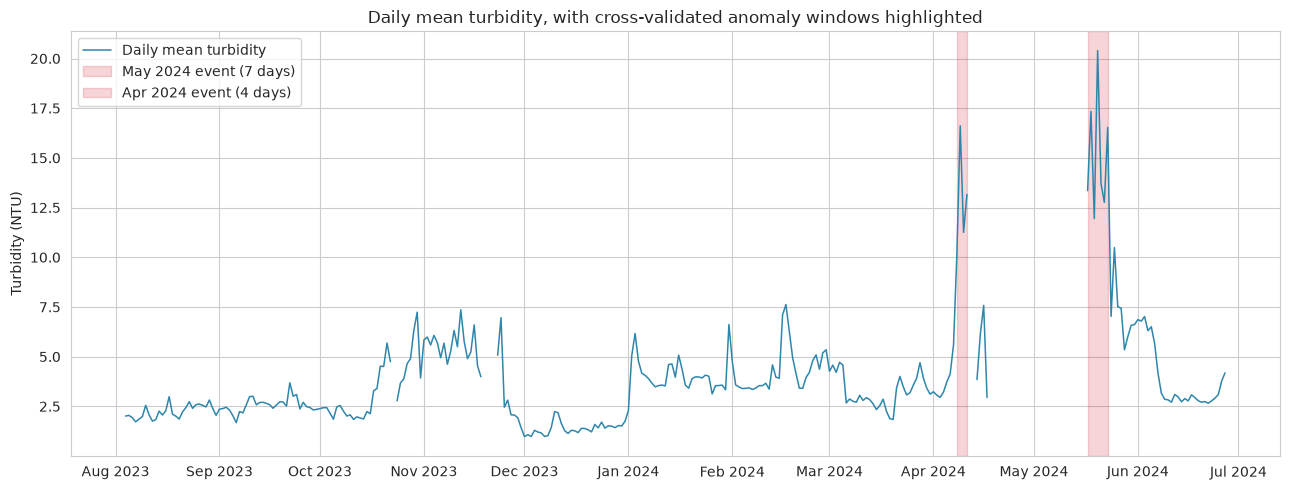

In [3]:
daily_turbidity = df.set_index('timestamp')['turbidity'].resample('D').mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_turbidity.index, daily_turbidity.values, color='#2E86AB', linewidth=1.1, label='Daily mean turbidity')

for start, end, label in [(*EVENT_1, 'May 2024 event (7 days)'), (*EVENT_2, 'Apr 2024 event (4 days)')]:
    ax.axvspan(start, end, color='#D62839', alpha=0.2, label=label)

ax.set_ylabel('Turbidity (NTU)')
ax.set_title('Daily mean turbidity, with cross-validated anomaly windows highlighted')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

**OBSERVATION:** Turbidity rises sharply and sustains an elevated level for 7 consecutive
days beginning the moment the buoy resumes logging on 17 May 2024, immediately after a
30-day equipment gap (mean 15.15 NTU, several times the dataset's typical level). A smaller
4-day elevation also occurred 8-11 April 2024, immediately before a separate ~3.4-day
equipment gap began.

**ENVIRONMENTAL INTERPRETATION:** A multi-day sustained elevation, rather than a single
noisy reading, is inconsistent with a brief instrument glitch, which typically produces
erratic single-point spikes rather than a smooth week-long rise and fall. However, the
timing of both events relative to equipment gaps is an important complication: the May
event begins the instant the sensor comes back online after a full month offline, and the
April event immediately precedes a separate outage. This timing is at least as consistent
with sensor biofouling buildup, post-outage recalibration drift, or physical disturbance
during buoy servicing as it is with a genuine rainfall/runoff event. The dataset alone
cannot distinguish between these explanations, and the timing arguably favours a
maintenance-related cause over a purely hydrological one.

**LIMITATION:** This dataset alone cannot confirm the cause, and the coincidence between
both turbidity events and equipment-outage boundaries means a purely hydrological
(rainfall) explanation should not be treated as the default assumption. Confirming the
true cause would require the monitoring program's own maintenance/service logs (to check
for a servicing or cleaning visit around these dates) alongside Bureau of Meteorology
rainfall records for the Brisbane area -- both are necessary future work, and neither
hypothesis is concluded here.

## Finding 2 — Seasonal temperature and dissolved oxygen move in opposite directions

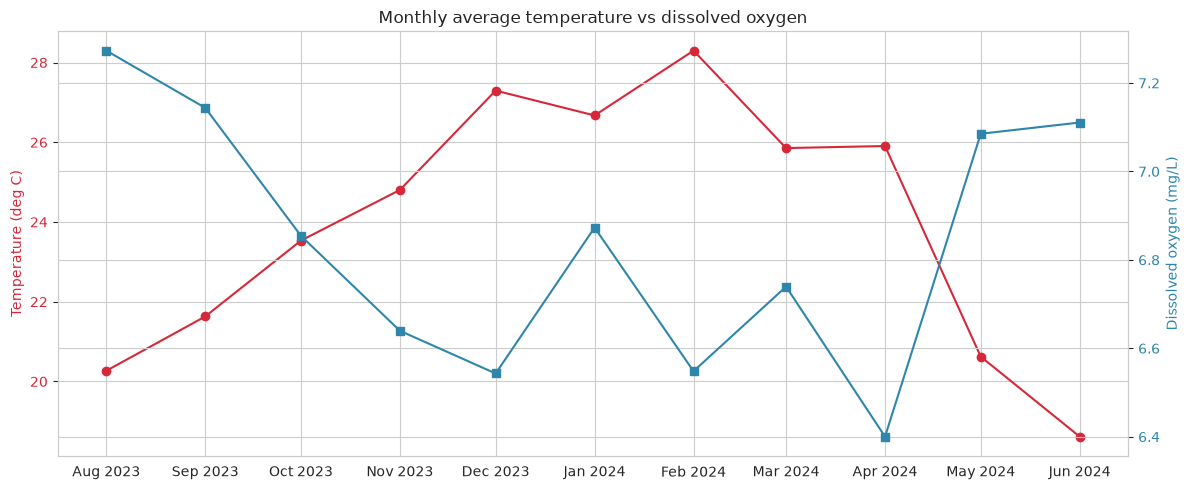

In [4]:
monthly = df.groupby(['year', 'month'], observed=True).agg(
    avg_temperature=('temperature', 'mean'),
    avg_dissolved_oxygen=('dissolved_oxygen', 'mean'),
).reset_index()
monthly['period'] = pd.to_datetime(monthly['year'].astype(str) + '-' + monthly['month'].astype(str) + '-01')
monthly = monthly.sort_values('period')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(monthly['period'], monthly['avg_temperature'], color='#D62839', marker='o', label='Avg temperature')
ax2.plot(monthly['period'], monthly['avg_dissolved_oxygen'], color='#2E86AB', marker='s', label='Avg dissolved oxygen')

ax1.set_ylabel('Temperature (deg C)', color='#D62839')
ax2.set_ylabel('Dissolved oxygen (mg/L)', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#D62839')
ax2.tick_params(axis='y', labelcolor='#2E86AB')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.set_title('Monthly average temperature vs dissolved oxygen')
fig.tight_layout()
plt.show()

**OBSERVATION:** Monthly average dissolved oxygen is lowest when temperature is highest
(summer) and highest when temperature is lowest (winter) -- the two lines move as mirror
images of each other across the monitoring period.

**ENVIRONMENTAL INTERPRETATION:** This pattern **is consistent with** a well-established
principle of water chemistry: colder water holds more dissolved gas (including oxygen) than
warmer water. This is not a novel discovery specific to this river, but confirming it in this
dataset is a useful sanity check that the sensor data behaves physically as expected.

**LIMITATION:** Only one annual cycle is available, so this shows a plausible seasonal
relationship rather than a statistically validated multi-year trend.

## Finding 3 — A clear daily (diel) oxygen cycle driven by daylight

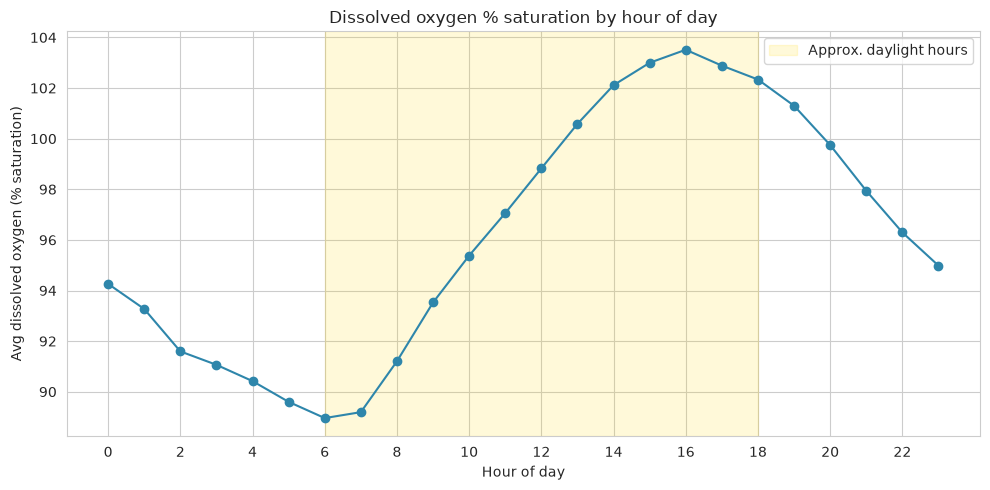

In [5]:
hourly = df.groupby('hour', observed=True)['dissolved_oxygen_pct_sat'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly.index, hourly.values, color='#2E86AB', marker='o', linewidth=1.5)
ax.axvspan(6, 18, color='gold', alpha=0.15, label='Approx. daylight hours')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg dissolved oxygen (% saturation)')
ax.set_title('Dissolved oxygen % saturation by hour of day')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

**OBSERVATION:** Dissolved oxygen % saturation is lowest in the early morning (around
6-7am) and rises through the day, peaking in the mid-to-late afternoon before declining
overnight.

**ENVIRONMENTAL INTERPRETATION:** This daily rhythm **is consistent with** photosynthesis by
algae and aquatic plants -- they produce oxygen during daylight and consume it (via
respiration, alongside all other organisms) overnight, a well-documented "diel oxygen cycle"
in river and estuarine ecosystems.

**LIMITATION:** This is an aggregate pattern averaged across the whole ~11-month period; the
strength of the cycle likely varies by season (e.g. stronger in summer with more daylight and
algal activity) -- not broken out separately here.

## Finding 4 — Distribution of turbidity readings, in context

Putting the May 2024 event in the context of the full distribution of readings.

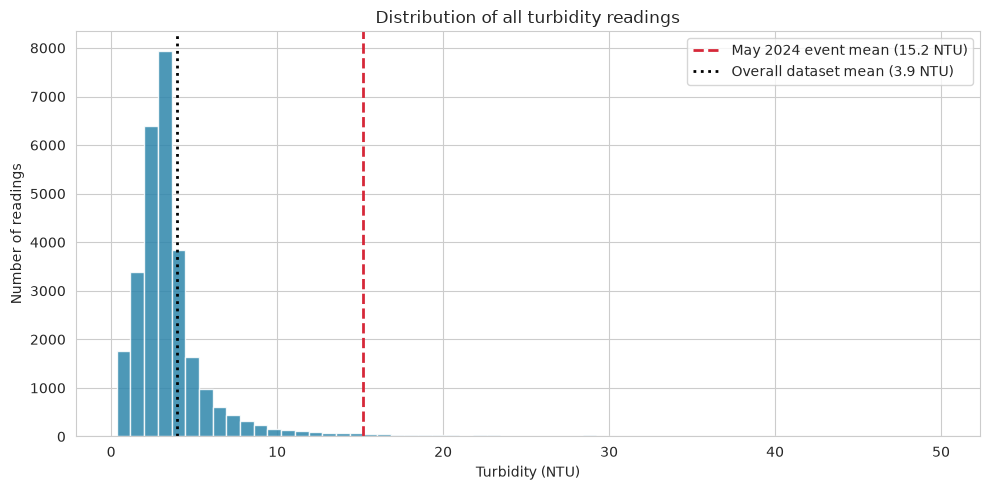

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
df['turbidity'].dropna().hist(bins=60, ax=ax, color='#2E86AB', edgecolor='white', alpha=0.85)

event_mask = df['timestamp'].between(*EVENT_1)
event_values = df.loc[event_mask, 'turbidity'].dropna()
ax.axvline(event_values.mean(), color='#D62839', linestyle='--', linewidth=2,
           label=f'May 2024 event mean ({event_values.mean():.1f} NTU)')
ax.axvline(df['turbidity'].mean(), color='black', linestyle=':', linewidth=2,
           label=f'Overall dataset mean ({df["turbidity"].mean():.1f} NTU)')

ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Number of readings')
ax.set_title('Distribution of all turbidity readings')
ax.legend()
plt.tight_layout()
plt.show()

**OBSERVATION:** The overall distribution is right-skewed, with most readings clustered
at low turbidity and a long tail of higher values. The May 2024 event's average sits well
into that tail, far from the dataset's typical reading.

**ENVIRONMENTAL INTERPRETATION:** A right-skewed distribution **is typical** of turbidity in
natural waterways -- most of the time conditions are calm and clear, punctuated occasionally
by high-turbidity events (rain, disturbance, runoff).

**LIMITATION:** A histogram alone doesn't show *when* the high values occurred -- that timing
information (shown in Finding 1) is what actually made the case for a real environmental
event rather than scattered noise.

## Finding 5 — Salinity varies by season, consistent with river flow dynamics

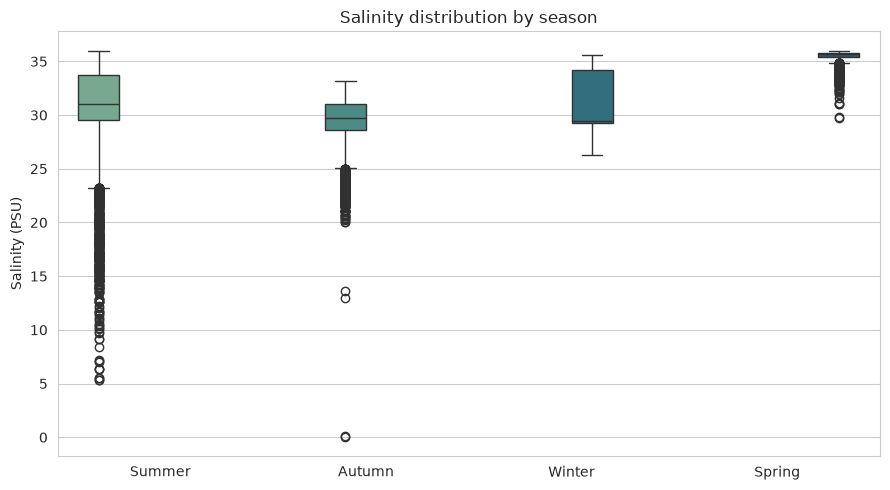

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='season', y='salinity', ax=ax, hue='season', palette='crest', legend=False)
ax.set_title('Salinity distribution by season')
ax.set_xlabel('')
ax.set_ylabel('Salinity (PSU)')
plt.tight_layout()
plt.show()

**OBSERVATION:** Salinity is generally higher and more concentrated in Summer/Autumn,
and comparatively lower/more variable in Winter/Spring.

**ENVIRONMENTAL INTERPRETATION:** This pattern **may indicate** reduced freshwater river flow
during drier months allowing more tidal/saline influence to reach further upstream, and
increased freshwater dilution during wetter months pushing salinity down.

**LIMITATION:** Salinity here is strongly correlated with specific conductance (r = 1.00,
identified in Notebook 2) since one is commonly derived from the other -- this is a property
of how the sensor calculates salinity, not two independent confirmations of the same finding.

## Finding 6 — Data completeness itself tells an environmental-engineering story

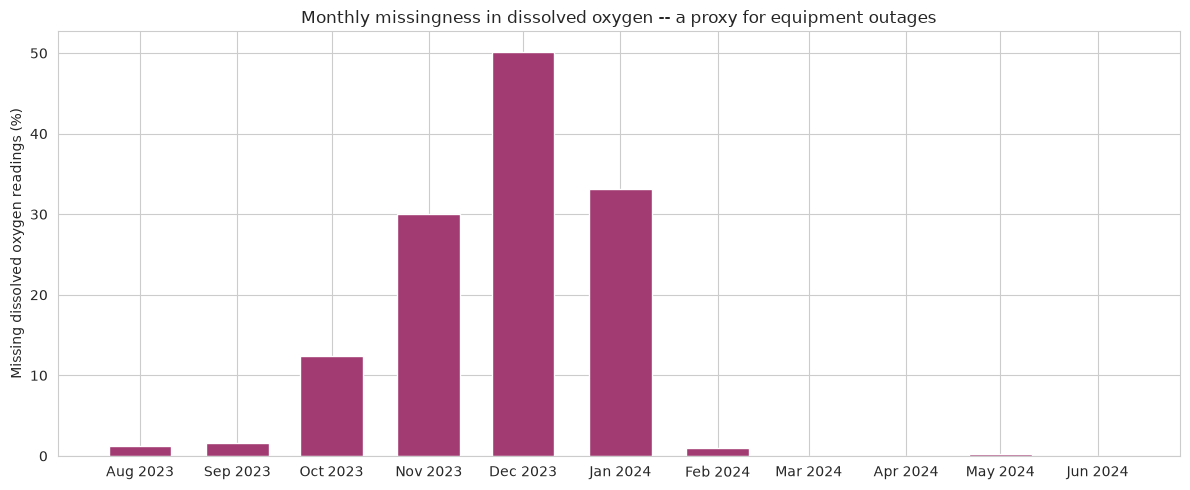

In [8]:
missing_by_month = df.groupby(['year', 'month'], observed=True)['dissolved_oxygen'].apply(
    lambda s: s.isna().mean() * 100
).reset_index(name='missing_pct')
missing_by_month['period'] = pd.to_datetime(
    missing_by_month['year'].astype(str) + '-' + missing_by_month['month'].astype(str) + '-01'
)
missing_by_month = missing_by_month.sort_values('period')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(missing_by_month['period'], missing_by_month['missing_pct'], width=20, color='#A23B72')
ax.set_ylabel('Missing dissolved oxygen readings (%)')
ax.set_title('Monthly missingness in dissolved oxygen -- a proxy for equipment outages')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

**OBSERVATION:** Missingness in dissolved oxygen is not evenly spread across the
monitoring period -- it clusters in specific months rather than occurring at a constant
background rate.

**ENVIRONMENTAL INTERPRETATION:** Clustered missingness **is consistent with** discrete
equipment outages or maintenance/biofouling periods rather than random sensor noise -- this
is exactly why Notebook 1's decision not to blindly impute or drop these rows was the right
call.

**LIMITATION:** This chart shows *when* data is missing, not *why* -- confirming the actual
cause would require the monitoring program's own equipment logs, outside this dataset.

## Summary

### Key findings
1. **Two turbidity events (8-11 April and 17-23 May 2024)** were independently confirmed
   by multiple methods (Python z-scores, SQL threshold query, SQL streak detection). Both
   events border equipment-outage periods, which is at least as consistent with sensor
   biofouling or post-outage disturbance as with a rainfall event (see Limitations).
2. **Temperature and dissolved oxygen move in opposite seasonal directions**, consistent
   with the physical relationship between water temperature and gas solubility.
3. **A daily (diel) oxygen cycle** driven by daylight/photosynthesis is clearly visible.
4. **Turbidity readings are right-skewed**, with the May 2024 event standing well outside
   the dataset's typical range.
5. **Salinity varies by season**, plausibly reflecting changing freshwater river-flow
   dilution versus tidal/saline influence across the year.
6. **Missing data is not random** -- it clusters into specific periods consistent with
   equipment outages, which is why Notebook 1 chose not to blindly clean it away.

### Environmental interpretation (overall)
Together, these findings paint a picture of a river site behaving broadly as expected for a
temperate, tidally-influenced Southern Hemisphere waterway -- with one clearly identified,
well-evidenced departure from typical conditions (the May 2024 turbidity event).

### Limitations
- Only ~11 months of data are available -- no finding here should be read as an established
  multi-year trend.
- No external data (rainfall, tides, upstream discharge, land-use) was used to confirm the
  *cause* of the May 2024 event -- only that a real, sustained event occurred.
- All correlational findings use wording like "associated with," "consistent with," and "may
  indicate" deliberately -- nothing in this project establishes causation.

### Recommendations for further investigation
- Cross-reference the May 2024 and April 2024 turbidity events against Bureau of
  Meteorology rainfall records AND the monitoring program's maintenance/service logs --
  since both events border equipment-outage periods, a maintenance-related cause is at
  least as plausible as rainfall and the two hypotheses need to be told apart.
- If multi-year data becomes available, repeat the seasonal and diel-cycle analysis to check
  whether these patterns are stable year-on-year rather than specific to this one period.
